# Обучение моделей

## 1. Импорты и настройка

In [1]:
import os, json, yaml, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from scipy import stats

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Создаём папки
os.makedirs('data/processed', exist_ok=True)

## 2. Загрузка параметров и данных

In [2]:
with open('params.yaml', 'r') as f:
    params = yaml.safe_load(f)

p = params['model_training']

df = pd.read_csv('data/raw/insurance.csv')

## 3. Подготовка признаков и целевой переменной

In [3]:
target = 'charges'

# Кодируем категориальные признаки
cat_cols = ['sex', 'smoker', 'region']
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

# Разделяем X и y
X = df.drop(target, axis=1)
y = df[target]

# Логарифмируем целевую переменную (по рекомендации EDA)
y_log = np.log1p(y)

## 4. Разделение на выборки данных

In [4]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y_log, test_size=p['test_size'], random_state=p['random_state']
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=p['valid_size']/(1-p['test_size']),
    random_state=p['random_state']
)

# Масштабирование числовых признаков (для нейронной сети и линейной регрессии)
scaler = StandardScaler()
num_cols = ['age', 'bmi', 'children']
X_train_scaled = X_train.copy()
X_valid_scaled = X_valid.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_valid_scaled[num_cols] = scaler.transform(X_valid[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print(f'Train size: {X_train.shape[0]}, Valid size: {X_valid.shape[0]}, Test size: {X_test.shape[0]}')

Train size: 870, Valid size: 125, Test size: 249


## 5. Словарь для сохранения метрик

In [5]:
all_metrics = {}

## 6. Линейная регрессия

In [6]:
print("=== Линейная регрессия ===")
lr_params = p['linear_regression']
lr = LinearRegression(fit_intercept=lr_params['fit_intercept'])
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

all_metrics['linear_regression'] = {
    'MSE': float(mse_lr),
    'MAE': float(mae_lr),
    'R2': float(r2_lr)
}
print(f"Коэффициенты: {dict(zip(X.columns, lr.coef_))}")
print(f"MSE: {mse_lr:.4f}, MAE: {mae_lr:.4f}, R2: {r2_lr:.4f}")

=== Линейная регрессия ===
Коэффициенты: {'age': np.float64(0.4949647728129329), 'sex': np.float64(-0.05635586643893323), 'bmi': np.float64(0.08950919968551832), 'children': np.float64(0.13179650156904552), 'smoker': np.float64(1.5629173733085402), 'region': np.float64(-0.05365328475454615)}
MSE: 0.2284, MAE: 0.2867, R2: 0.7237


## 7. Дерево решений


=== Дерево решений ===
MSE: 0.1712, MAE: 0.2309, R2: 0.7928


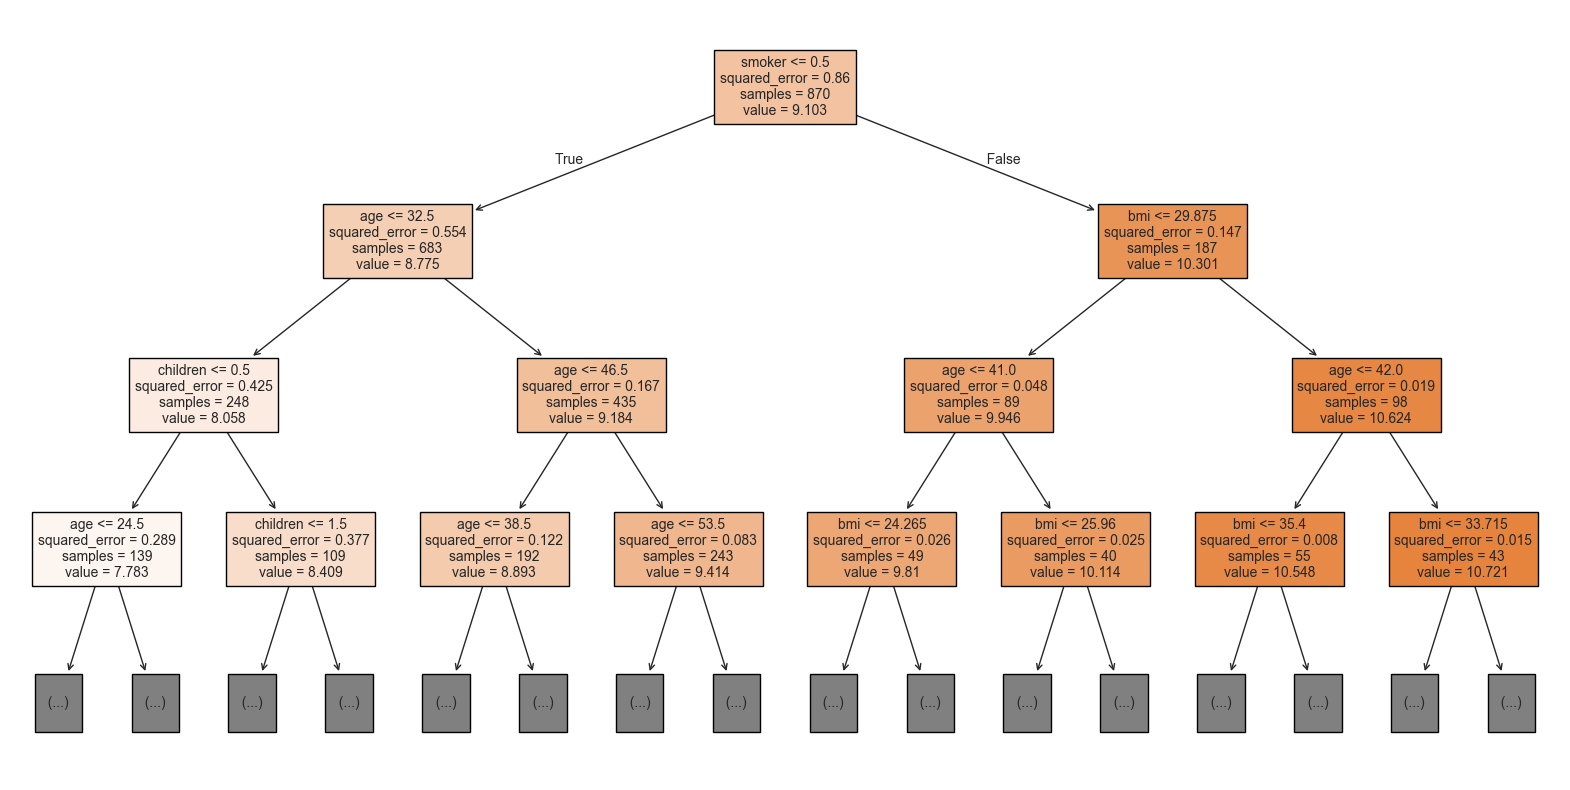

In [7]:
print("\n=== Дерево решений ===")
dt_params = p['decision_tree']
dt = DecisionTreeRegressor(
    max_depth=dt_params['max_depth'],
    min_samples_split=dt_params['min_samples_split'],
    min_samples_leaf=dt_params['min_samples_leaf'],
    random_state=p['random_state']
)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

mse_dt = mean_squared_error(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

all_metrics['decision_tree'] = {
    'MSE': float(mse_dt),
    'MAE': float(mae_dt),
    'R2': float(r2_dt)
}
print(f"MSE: {mse_dt:.4f}, MAE: {mae_dt:.4f}, R2: {r2_dt:.4f}")

# Рисунок первых узлов дерева
plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=X.columns, filled=True, max_depth=3, fontsize=10)
plt.savefig('data/processed/decision_tree_first_nodes.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. CatBoost


=== CatBoost ===
MSE: 0.1707, MAE: 0.2553, R2: 0.7935


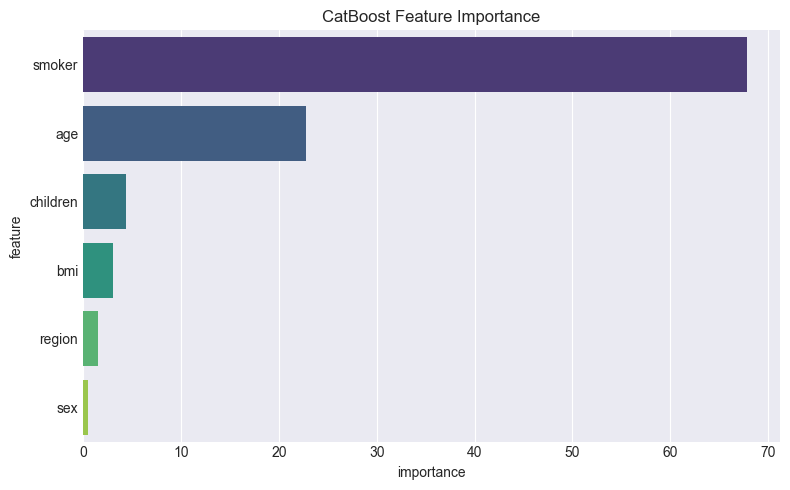

In [8]:
print("\n=== CatBoost ===")
cb_params = p['catboost']
cb = CatBoostRegressor(
    iterations=cb_params['iterations'],
    learning_rate=cb_params['learning_rate'],
    depth=cb_params['depth'],
    verbose=cb_params['verbose'],
    random_seed=p['random_state']
)
cb.fit(X_train, y_train, eval_set=(X_valid, y_valid), early_stopping_rounds=50)

y_pred_cb = cb.predict(X_test)

mse_cb = mean_squared_error(y_test, y_pred_cb)
mae_cb = mean_absolute_error(y_test, y_pred_cb)
r2_cb = r2_score(y_test, y_pred_cb)

all_metrics['catboost'] = {
    'MSE': float(mse_cb),
    'MAE': float(mae_cb),
    'R2': float(r2_cb)
}
print(f"MSE: {mse_cb:.4f}, MAE: {mae_cb:.4f}, R2: {r2_cb:.4f}")

# Feature Importance
plt.figure(figsize=(8,5))
imp_df = pd.DataFrame({
    'feature': X.columns,
    'importance': cb.feature_importances_
}).sort_values('importance', ascending=False)
sns.barplot(data=imp_df, x='importance', y='feature', palette='viridis')
plt.title('CatBoost Feature Importance')
plt.tight_layout()
plt.savefig('data/processed/feature_importance_catboost.png')
plt.show()

## 9. XGBoost


=== XGBoost ===
MSE: 0.1613, MAE: 0.1998, R2: 0.8048


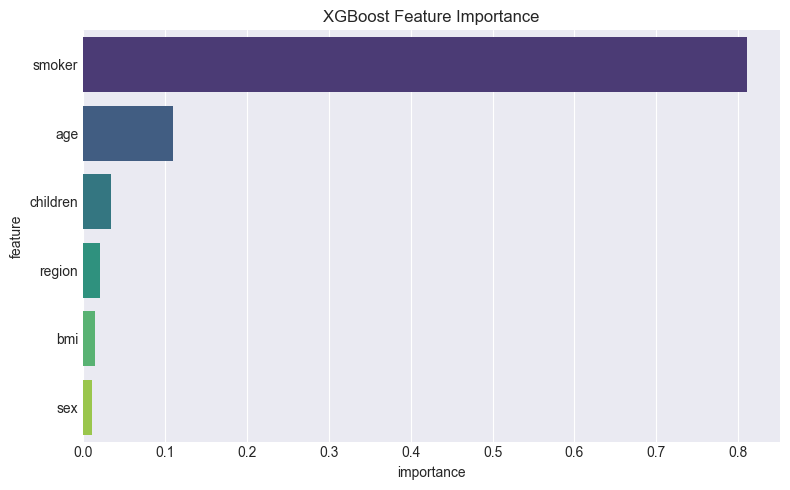

In [9]:
print("\n=== XGBoost ===")
xgb_params = p['xgboost']
xgb = XGBRegressor(
    n_estimators=xgb_params['n_estimators'],
    max_depth=xgb_params['max_depth'],
    learning_rate=xgb_params['learning_rate'],
    verbosity=xgb_params['verbosity'],
    random_state=p['random_state']
)
xgb.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)

y_pred_xgb = xgb.predict(X_test)

mse_xgb = mean_squared_error(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

all_metrics['xgboost'] = {
    'MSE': float(mse_xgb),
    'MAE': float(mae_xgb),
    'R2': float(r2_xgb)
}
print(f"MSE: {mse_xgb:.4f}, MAE: {mae_xgb:.4f}, R2: {r2_xgb:.4f}")

# Feature Importance
plt.figure(figsize=(8,5))
imp_df_xgb = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False)
sns.barplot(data=imp_df_xgb, x='importance', y='feature', palette='viridis')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.savefig('data/processed/feature_importance_xgboost.png')
plt.show()

## 10. Нейронная сеть


=== Нейронная сеть (MLPRegressor) ===
MSE: 0.1725, MAE: 0.2136, R2: 0.7913


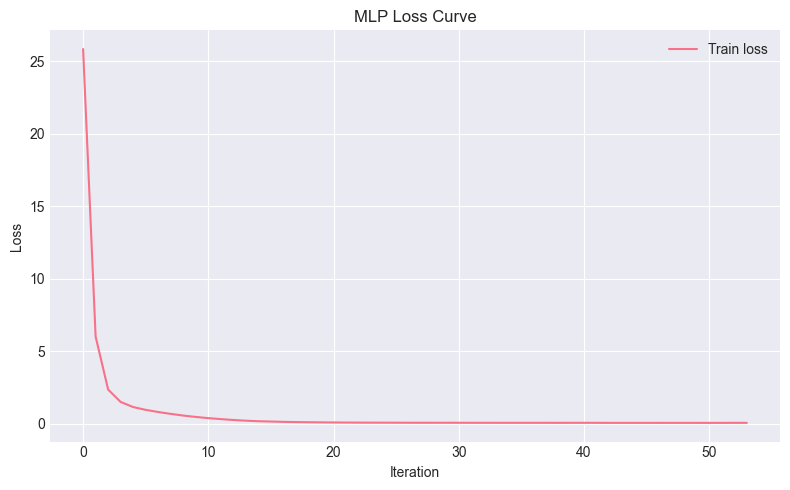

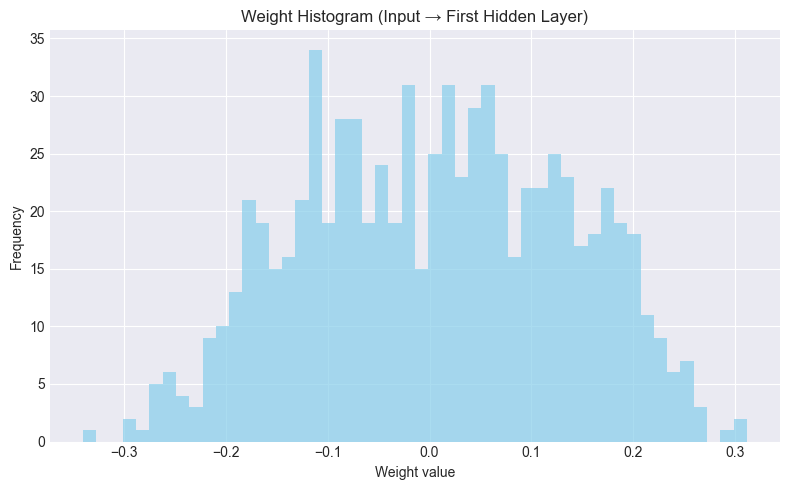

In [10]:
from sklearn.neural_network import MLPRegressor

print("\n=== Нейронная сеть (MLPRegressor) ===")
nn_params = p['neural_network']

mlp = MLPRegressor(
    hidden_layer_sizes=nn_params['hidden_layer_sizes'],
    activation=nn_params['activation'],
    solver=nn_params['solver'],
    alpha=nn_params['alpha'],
    batch_size=nn_params['batch_size'],
    learning_rate_init=nn_params['learning_rate_init'],
    max_iter=nn_params['max_iter'],
    early_stopping=nn_params['early_stopping'],
    validation_fraction=nn_params['validation_fraction'],
    random_state=nn_params['random_state'],
    verbose=False
)

mlp.fit(X_train_scaled, y_train)

y_pred_nn = mlp.predict(X_test_scaled)

mse_nn  = mean_squared_error(y_test, y_pred_nn)
mae_nn  = mean_absolute_error(y_test, y_pred_nn)
r2_nn   = r2_score(y_test, y_pred_nn)

all_metrics['neural_network'] = {
    'MSE': float(mse_nn),
    'MAE': float(mae_nn),
    'R2' : float(r2_nn)
}
print(f"MSE: {mse_nn:.4f}, MAE: {mae_nn:.4f}, R2: {r2_nn:.4f}")

# Кривая потерь по эпохам
plt.figure(figsize=(8,5))
plt.plot(mlp.loss_curve_, label='Train loss')
plt.title('MLP Loss Curve')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('data/processed/nn_training_history.png')
plt.show()

# Сохраняем кривую для DVC plots
loss_df = pd.DataFrame({
    'iteration': range(len(mlp.loss_curve_)),
    'loss': mlp.loss_curve_
})
loss_df.to_csv('data/processed/nn_training_curves.csv', index=False)

# Гистограмма весов первого скрытого слоя
plt.figure(figsize=(8,5))
weights_input_hidden = mlp.coefs_[0].ravel()
plt.hist(weights_input_hidden, bins=50, alpha=0.7, color='skyblue')
plt.title('Weight Histogram (Input → First Hidden Layer)')
plt.xlabel('Weight value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('data/processed/nn_weight_histograms.png')
plt.show()

## 11. Сохранение всех метрик

In [11]:
with open('data/processed/all_models_metrics.json', 'w') as f:
    json.dump(all_metrics, f, indent=2)

print("\nВсе метрики сохранены в data/processed/all_models_metrics.json")


Все метрики сохранены в data/processed/all_models_metrics.json
